# Image Classification with CNN — MNIST

## 1. MNIST Dataset

The MNIST dataset, introduced by Yann LeCun, Corinna Cortes, and Christopher Burges, contains 60,000 training samples and 10,000 test samples. Each sample is a 28×28 grayscale image representing one of 10 handwritten digits (0–9). The dataset is approximately balanced, with each class comprising about 9%–11% of the data.

---

## 2. Convolutional Neural Network (CNN) Model  

### 2.1 Model Architecture
- **Input:** 1×28×28 (grayscale images)  
- **Convolutional Layers:**  
  - Layer 1: 32 filters, kernel size 3×3, stride 1, ReLU activation  
  - Layer 2: 64 filters, kernel size 3×3, stride 1, ReLU activation  
- **Pooling Layers:**  
  - Max pooling (2×2) to reduce spatial dimensions and retain key features  
- **Fully Connected Layers:**  
  - Dense Layer: Flattened feature maps (1600 units) → 64 neurons, ReLU activation  
  - Output Layer: 10 neurons with Softmax activation, producing class probabilities for digits 0–9  

---

### 2.2 Hyperparameters
- Learning rate: 0.001 (controls step size during optimization)  
- Batch size: 32  
- Epochs: 10  

---

### 2.3 Optimization Technique
- Optimizer: Adam (Adaptive Moment Estimation), which uses estimates of the first moment (mean of gradients) and second moment (variance of gradients) to adapt learning rates during training  

---

### 2.4 Evaluation
- Loss function: Categorical cross-entropy  
- Accuracy:  
  - Training accuracy: 99.92%  
  - Validation accuracy: 99.15%  
  - Test accuracy: 99.14%  

The model achieves high accuracy with minimal gap between training and validation performance, indicating good generalization and limited overfitting.

In [ ]:
# Install packages
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install torchsummary    

In [23]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils as utils
from torch.utils.data import random_split, DataLoader
from torchsummary import summary
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [24]:
# Define transformation for normalization
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]) # Normalization based on mean and std of dataset
# Load the training and test dataset
training_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [25]:
print(f"Training data size: {len(training_data)}")
print(f"Testing data: {len(test_dataset)}")

Training data size: 60000
Testing data: 10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


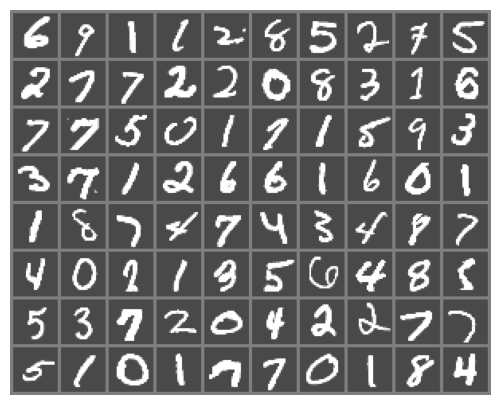

Labels: ['6 - six', '9 - nine', '1 - one', '1 - one', '2 - two', '8 - eight', '5 - five', '2 - two', '7 - seven', '5 - five', '2 - two', '7 - seven', '7 - seven', '2 - two', '2 - two', '0 - zero', '8 - eight', '3 - three', '1 - one', '6 - six', '7 - seven', '7 - seven', '5 - five', '0 - zero', '1 - one', '7 - seven', '1 - one', '5 - five', '9 - nine', '3 - three', '3 - three', '7 - seven', '1 - one', '2 - two', '6 - six', '6 - six', '1 - one', '6 - six', '0 - zero', '1 - one', '1 - one', '8 - eight', '7 - seven', '4 - four', '7 - seven', '4 - four', '3 - three', '4 - four', '8 - eight', '7 - seven', '4 - four', '0 - zero', '2 - two', '1 - one', '3 - three', '5 - five', '6 - six', '4 - four', '8 - eight', '5 - five', '5 - five', '3 - three', '7 - seven', '2 - two', '0 - zero', '4 - four', '2 - two', '2 - two', '7 - seven', '7 - seven', '5 - five', '1 - one', '0 - zero', '1 - one', '7 - seven', '7 - seven', '0 - zero', '1 - one', '8 - eight', '4 - four']


In [26]:
# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get a batch of training data
dataiter = iter(torch.utils.data.DataLoader(training_data, batch_size=80, shuffle=True))
images, labels = next(dataiter)

# Show images
plt.figure(figsize=(10, 5))  
imshow(torchvision.utils.make_grid(images, nrow=10)) 

# Print corresponding labels
print('Labels:', [training_data.classes[label] for label in labels])

In [27]:
# Define split ratios for training and validation 
train_size = 50000
val_size = 10000

# Perform the random split
train_dataset, val_dataset = random_split(training_data, [train_size, val_size], generator=torch.Generator().manual_seed(74)) 

# Create DataLoaders for efficient batching 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Training dataset size: 50000
Validation dataset size: 10000
Test dataset size: 10000


In [28]:
# Define CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolution layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64*5*5, 64) 
        self.fc2 = nn.Linear(64, 10)  
        
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)       
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)  
        x = self.relu(self.fc1(x)) 
        x = self.fc2(x)
 
        return x

In [29]:
# Initialize model, define the loss function and the optimizer
model = CNN() # Creates instance of MNIST class
criterion = nn.CrossEntropyLoss() # Defines loss function 
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization and learning rate

In [30]:
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [31]:
# Parameter Count
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Print model summary
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
              ReLU-2           [-1, 32, 26, 26]               0
         MaxPool2d-3           [-1, 32, 13, 13]               0
            Conv2d-4           [-1, 64, 11, 11]          18,496
              ReLU-5           [-1, 64, 11, 11]               0
         MaxPool2d-6             [-1, 64, 5, 5]               0
            Linear-7                   [-1, 64]         102,464
              ReLU-8                   [-1, 64]               0
            Linear-9                   [-1, 10]             650
Total params: 121,930
Trainable params: 121,930
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.50
Params size (MB): 0.47
Estimated Total Size (MB): 0.97
-------------------------------------------

In [55]:
# Train model
num_epochs = 10 # Defines number of epochs (iterations)

train_acc_list = [] # Initializes an empty list to store training accuracy per epoch
val_acc_list = [] # Initializes an empty list to store validation accuracy per epoch

train_loss_list = [] # Initializes an empty list to store training loss per epoch
val_loss_list = [] # Initializes an empty list to store validation loss per epoch

for epoch in range(num_epochs): # Model to train 10 epochs over dataset
    # Training phase
    model.train() # Activares training mode
    running_loss = 0 # Resets tracking variable
    correct, total = 0, 0 # Resets tracking variables

    for data, target in train_loader: # Loops through training data in batches
        optimizer.zero_grad() # Zero out out previous gradients
        output = model(data) # Forward pass
        loss = criterion(output, target) # Computes loss, output predictions vs target labels
        loss.backward() # Backward pass and gradient calculation
        optimizer.step() # Updates model weights based on computed gradients
        
        running_loss += loss.item() # Accumulates total loss for the current epoch
        _, predicted = torch.max(output, 1) # Finds highest scoring class for each image, stores predicted labels 
        total += target.size(0) # Counts processed samples
        correct += (predicted == target).sum().item() # Tracks how many predictions were correct

    train_accuracy = 100 * correct / total # Calculates accuracy
    train_acc_list.append(train_accuracy) # Appends accuracy per epoch
    avg_train_loss = running_loss / len(train_loader) # Calculates average loss 
    train_loss_list.append(avg_train_loss) # Appends loss per epoch 
    
    # Validation phase
    model.eval() # Activates evaluation mode
    val_loss = 0 # Resets tracking variable
    correct_val, total_val = 0, 0 # Resets tracking variables

    with torch.no_grad():  # Disables gradient updates for validation
        for data, target in val_loader: # Loops through validation data in batches
            output = model(data) # Forward pass
            loss = criterion(output, target) # Computes loss, outputs predictions vs target labels
            
            val_loss += loss.item() # Accumulates validation total loss for the current epoch
            _, predicted = torch.max(output, 1) # Finds highest scoring class for each image, stores predicted labels 
            total_val += target.size(0) # Counts processed samples
            correct_val += (predicted == target).sum().item() # Tracks how many predictions were correct

    val_accuracy = 100 * correct_val / total_val # Calculates validation accuracy
    val_acc_list.append(val_accuracy) # Appends accuracy per epoch
    avg_val_loss = val_loss / len(val_loader) # Calculates average loss 
    val_loss_list.append(avg_val_loss) # Appends loss per epoch 
    
    # Print Metrics
    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.2f}% | Val Loss = {avg_val_loss:.4f}, Val Acc = {val_accuracy:.2f}%")

Epoch 1: Train Loss = 0.0036, Train Acc = 99.91% | Val Loss = 0.0774, Val Acc = 99.14%
Epoch 2: Train Loss = 0.0024, Train Acc = 99.93% | Val Loss = 0.0998, Val Acc = 98.99%
Epoch 3: Train Loss = 0.0044, Train Acc = 99.90% | Val Loss = 0.1057, Val Acc = 98.85%
Epoch 4: Train Loss = 0.0018, Train Acc = 99.94% | Val Loss = 0.1144, Val Acc = 99.10%
Epoch 5: Train Loss = 0.0048, Train Acc = 99.88% | Val Loss = 0.0985, Val Acc = 99.08%
Epoch 6: Train Loss = 0.0013, Train Acc = 99.96% | Val Loss = 0.1049, Val Acc = 99.09%
Epoch 7: Train Loss = 0.0068, Train Acc = 99.85% | Val Loss = 0.0877, Val Acc = 99.10%
Epoch 8: Train Loss = 0.0039, Train Acc = 99.90% | Val Loss = 0.0916, Val Acc = 99.12%
Epoch 9: Train Loss = 0.0038, Train Acc = 99.91% | Val Loss = 0.0810, Val Acc = 99.17%
Epoch 10: Train Loss = 0.0031, Train Acc = 99.92% | Val Loss = 0.0881, Val Acc = 99.15%


In [56]:
# Calculate Test Accuracy
correct, total = 0, 0 # Resets tracking variables

model.eval()  # Set model to evaluation mode
with torch.no_grad():  # Disable gradient tracking for efficiency
    for data, target in test_loader:  # Iterate over test batches
        output = model(data)  # Forward pass
        _, predicted = torch.max(output, 1)  # Get predicted class labels
        total += target.size(0)  # Count total test samples
        correct += (predicted == target).sum().item()  # Count correct predictions

test_accuracy = 100 * correct / total # Calculate test accuracy

# Print Metric
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 99.14%


### 2.5 Accuracy and Loss Plots

The validation accuracy shows a small dip between epochs 2 and 4, followed by a gradual increase until around epoch 9, with a slight decrease toward the final epoch. These fluctuations are minor and partly due to the plot’s narrow scale (range ≈ 0.2), which visually amplifies small changes. The variability can also be attributed to batch-to-batch stochasticity during training.

The validation loss exhibits more variability but follows an overall decreasing trend after epoch 4, indicating improving model performance. The scale of the loss plot is very small (range ≈ 0.02), so the apparent fluctuations are minimal in magnitude.

Potential improvements such as reducing the learning rate or applying regularization techniques (e.g., dropout or weight decay) could further smooth the training curves. However, given the high validation accuracy (99.15%) and the small gap between training and validation performance, the model already demonstrates strong generalization, and additional gains are likely to be marginal.

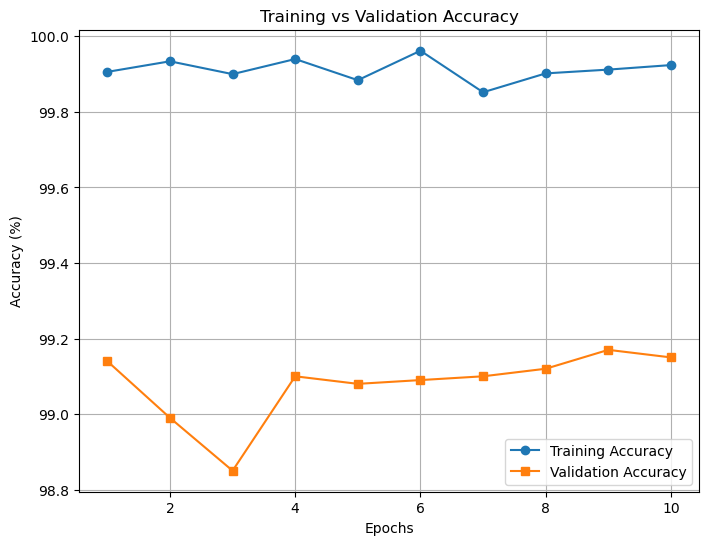

In [57]:
# Plot Training vs Validation Accuracy
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs+1), train_acc_list, label="Training Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_acc_list, label="Validation Accuracy", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

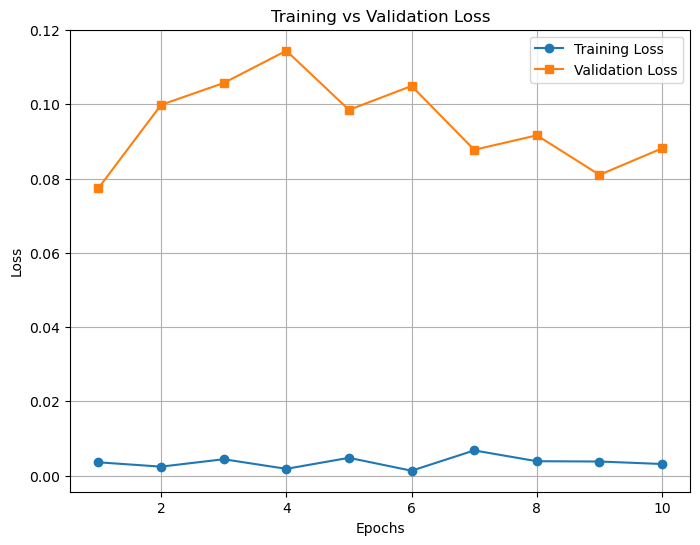

In [58]:
# Plot Training vs Validation Loss
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs+1), train_loss_list, label="Training Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_loss_list, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

### 2.6 Per-Class Accuracy

The model performs consistently well across all classes on the test set, with eight digits achieving accuracy above 99% and the remaining two exceeding 98%.

Digit "1" has the highest accuracy (99.74%), likely due to its simple and consistent structure, which makes it easier for the model to learn distinguishing features. In contrast, digit "9" has the lowest accuracy (98.22%), likely due to greater visual similarity with other digits such as "4" and "7", leading to occasional misclassification.

The strong performance across all classes reflects the relatively low complexity of the MNIST dataset. The digits have simple shapes, minimal variation, and clean backgrounds, allowing a CNN with a small number of convolutional layers to learn effective feature representations.

In contrast, the CIFAR-10 dataset presents a more challenging problem. It consists of RGB images (three channels) of real-world objects with greater variability in shape, texture, and background, as well as lower resolution. This increased complexity makes classification significantly more difficult and requires more advanced modeling approaches.

In [59]:
# Calculate per class accuracy
# Initialize counters for each digit (0–9)
class_correct = [0] * 10
class_total = [0] * 10

model.eval()  # Set model to evaluation mode
with torch.no_grad():  # Disable gradient tracking
    for data, target in test_loader:  # Iterate over test set
        output = model(data)  # Forward pass
        _, predicted = torch.max(output, 1)  # Get predicted labels

        # Update correct count per class
        for i in range(len(target)):
            label = target[i].item()
            pred = predicted[i].item()
            if label == pred:
                class_correct[label] += 1
            class_total[label] += 1  # Track total samples per class

# Print accuracy per class
for i in range(10):  # Loop over digit classes (0–9)
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        print(f"Accuracy for digit {i}: {accuracy:.2f}%")
    else:
        print(f"No samples found for digit {i}")

Accuracy for digit 0: 99.69%
Accuracy for digit 1: 99.74%
Accuracy for digit 2: 99.32%
Accuracy for digit 3: 99.50%
Accuracy for digit 4: 99.29%
Accuracy for digit 5: 99.10%
Accuracy for digit 6: 98.33%
Accuracy for digit 7: 99.03%
Accuracy for digit 8: 99.08%
Accuracy for digit 9: 98.22%
